# Pruebas

In [2]:
import matplotlib.pyplot as plt
import pandas
import numpy
import joblib

## Trabajamos con los mismos datos

In [3]:
Y = joblib.load('variables/ventas_helado.joblib')
X = joblib.load('variables/temperatura.joblib')

### Lista de valores genereados con la ecuacion

In [4]:
a = joblib.load('variables/a.joblib')
b = joblib.load('variables/b.joblib')
a, b = float(a), float(b)
y_aproximado = [ a + b*x for x in X ]


## Error

### Error porcentual del calculo de 'y' calculado y 'Y'
Vamos a obtener los calculos realizados con los valores obtenidos de 'a' y 'b'. Y comparamos con 'Y'

In [5]:
error_porcentual = [ round(abs(y_calc - y_d)/abs(y_d) * 100, 2) for y_calc, y_d in zip(y_aproximado, Y)]
dic1 = {
    'Esperado': Y,
    'Calculado': y_aproximado,
    'Error %': error_porcentual
}

df1 = pandas.DataFrame(dic1)
df1

,Esperado,Calculado,Error %
0,52.868102,45.596829,13.75
1,40.333411,46.825250,16.10
2,57.299028,48.053671,16.14
3,61.739083,49.282092,20.18
4,62.150140,50.510513,18.73
...,...,...,...
95,163.124528,162.296813,0.51
96,160.575163,163.525234,1.84
97,154.136197,164.753655,6.89
98,157.758258,165.982076,5.21


### Error porcentual del calculo de 'y' por minimos cuadrados y 'Y'
Vamos a obtener los calculos realizados con los valores obtenidos de 'a' y 'b' por minimos cuadrados. Y comparamos con 'Y'

In [6]:
_b, _a = numpy.polyfit(X, Y, 1)
y_regresion_linear = [ _a + _b*x for x in X ]
error_porcentual = [ round(abs(y_reg - y_d)/abs(y_d) * 100, 2) for y_reg, y_d in zip(y_regresion_linear, Y)]

dic2 = {
    'Esperado': Y,
    'Calculado': y_regresion_linear,
    'Error %': error_porcentual
}
df2 = pandas.DataFrame(dic2)
df2

,Esperado,Calculado,Error %
0,52.868102,50.929835,3.67
1,40.333411,52.050720,29.05
2,57.299028,53.171606,7.20
3,61.739083,54.292491,12.06
4,62.150140,55.413376,10.84
...,...,...,...
95,163.124528,157.413949,3.50
96,160.575163,158.534834,1.27
97,154.136197,159.655720,3.58
98,157.758258,160.776605,1.91


### Error de Y aproximado respecto a Y por mínimos cuadrados

Error porcentual para a

In [7]:
float(abs(a - _a) / abs(_a) * 100)

3582.6304379753574

Error porcentual para b

In [8]:
float(abs(b - _b) / abs(_b) * 100)

9.593797168839519

## Gráficas

### Gráfica con minimos cuadrados

a = -0.2860063268264071, b = 4.267986760400485


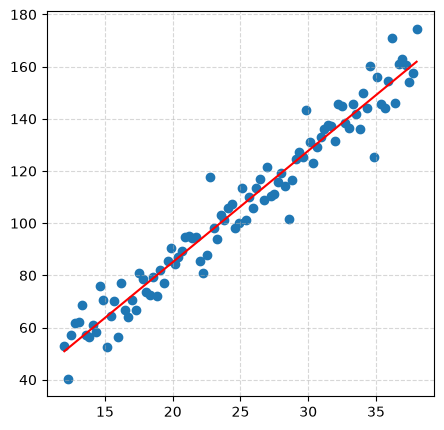

In [9]:
_b, _a = numpy.polyfit(X, Y, 1)
print(f'a = {_a}, b = {_b}')

plt.figure(figsize=(5, 5))
plt.scatter(X, Y,)
plt.grid(True, linestyle='--', alpha=0.5)

plt.plot(X, _b*numpy.array(X) + _a, color="red")
plt.show()


### Gráfica con cálculo de 'a' y 'b' 

a = -10.532556046244546 b = 4.677448753386233


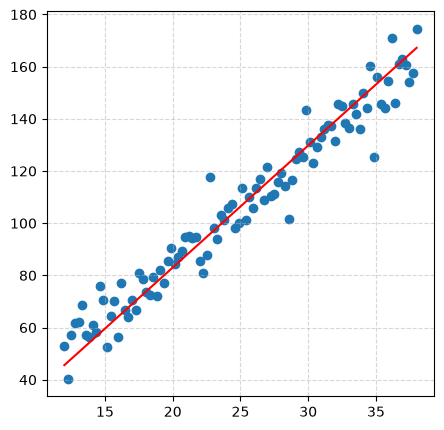

In [10]:
print(f'a = {a}', f'b = {b}')
plt.figure(figsize=(5,5))
plt.scatter(X, Y, label="Datos")
plt.grid(True, linestyle='--', alpha=0.5)
plt.plot(X, b*numpy.array(X) + a, color="red")
plt.show()

In [11]:
f = lambda x: a + b*x
f(40)

176.56539408920477